In [1]:
# Import Dataset
from pathlib import Path
import pandas as pd

# Project root directory
ROOT_DIR = Path.cwd().parent

# Merged Dataset 
DATASET_PATH = ROOT_DIR / "Datasets"  / "merged" / "crypto_master.csv"

df = pd.read_csv(DATASET_PATH)
df.head()

,SNo,Name,Symbol,Date,High,Low,Open,Close,Volume,Marketcap,Crypto
0,1,Aave,AAVE,2020-10-05 23:59:59,55.112358,49.787900,52.675035,53.219243,0.000000e+00,8.912813e+07,Aave
1,2,Aave,AAVE,2020-10-06 23:59:59,53.402270,40.734578,53.291969,42.401599,5.830915e+05,7.101144e+07,Aave
2,3,Aave,AAVE,2020-10-07 23:59:59,42.408314,35.970690,42.399947,40.083976,6.828342e+05,6.713004e+07,Aave
3,4,Aave,AAVE,2020-10-08 23:59:59,44.902511,36.696057,39.885262,43.764463,1.658817e+06,2.202651e+08,Aave
4,5,Aave,AAVE,2020-10-09 23:59:59,47.569533,43.291776,43.764463,46.817744,8.155377e+05,2.356322e+08,Aave


In [2]:
# Basic dataset overview

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

Shape: (37082, 11)

Columns:
['SNo', 'Name', 'Symbol', 'Date', 'High', 'Low', 'Open', 'Close', 'Volume', 'Marketcap', 'Crypto']

Data Types:
SNo            int64
Name             str
Symbol           str
Date             str
High         float64
Low          float64
Open         float64
Close        float64
Volume       float64
Marketcap    float64
Crypto           str
dtype: object

First 5 rows:


,SNo,Name,Symbol,Date,High,Low,Open,Close,Volume,Marketcap,Crypto
0,1,Aave,AAVE,2020-10-05 23:59:59,55.112358,49.787900,52.675035,53.219243,0.000000e+00,8.912813e+07,Aave
1,2,Aave,AAVE,2020-10-06 23:59:59,53.402270,40.734578,53.291969,42.401599,5.830915e+05,7.101144e+07,Aave
2,3,Aave,AAVE,2020-10-07 23:59:59,42.408314,35.970690,42.399947,40.083976,6.828342e+05,6.713004e+07,Aave
3,4,Aave,AAVE,2020-10-08 23:59:59,44.902511,36.696057,39.885262,43.764463,1.658817e+06,2.202651e+08,Aave
4,5,Aave,AAVE,2020-10-09 23:59:59,47.569533,43.291776,43.764463,46.817744,8.155377e+05,2.356322e+08,Aave



Last 5 rows:


,SNo,Name,Symbol,Date,High,Low,Open,Close,Volume,Marketcap,Crypto
37077,2889,XRP,XRP,2021-07-02 23:59:59,0.667287,0.634726,0.659890,0.656763,2.061607e+09,3.030759e+10,XRP
37078,2890,XRP,XRP,2021-07-03 23:59:59,0.683677,0.644653,0.655639,0.672888,1.872820e+09,3.105172e+10,XRP
37079,2891,XRP,XRP,2021-07-04 23:59:59,0.707783,0.665802,0.673218,0.694945,1.885242e+09,3.206960e+10,XRP
37080,2892,XRP,XRP,2021-07-05 23:59:59,0.695653,0.648492,0.695653,0.654300,2.076373e+09,3.019395e+10,XRP
37081,2893,XRP,XRP,2021-07-06 23:59:59,0.679923,0.652676,0.653055,0.665402,1.938959e+09,3.072284e+10,XRP


In [3]:
df["Date"] = pd.to_datetime(
    df["Date"],
    format="mixed"
)

print("\n Info")
print(df.info())


 Info
<class 'pandas.DataFrame'>
RangeIndex: 37082 entries, 0 to 37081
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   SNo        37082 non-null  int64         
 1   Name       37082 non-null  str           
 2   Symbol     37082 non-null  str           
 3   Date       37082 non-null  datetime64[us]
 4   High       37082 non-null  float64       
 5   Low        37082 non-null  float64       
 6   Open       37082 non-null  float64       
 7   Close      37082 non-null  float64       
 8   Volume     37082 non-null  float64       
 9   Marketcap  37082 non-null  float64       
 10  Crypto     37082 non-null  str           
dtypes: datetime64[us](1), float64(6), int64(1), str(3)
memory usage: 3.7 MB
None


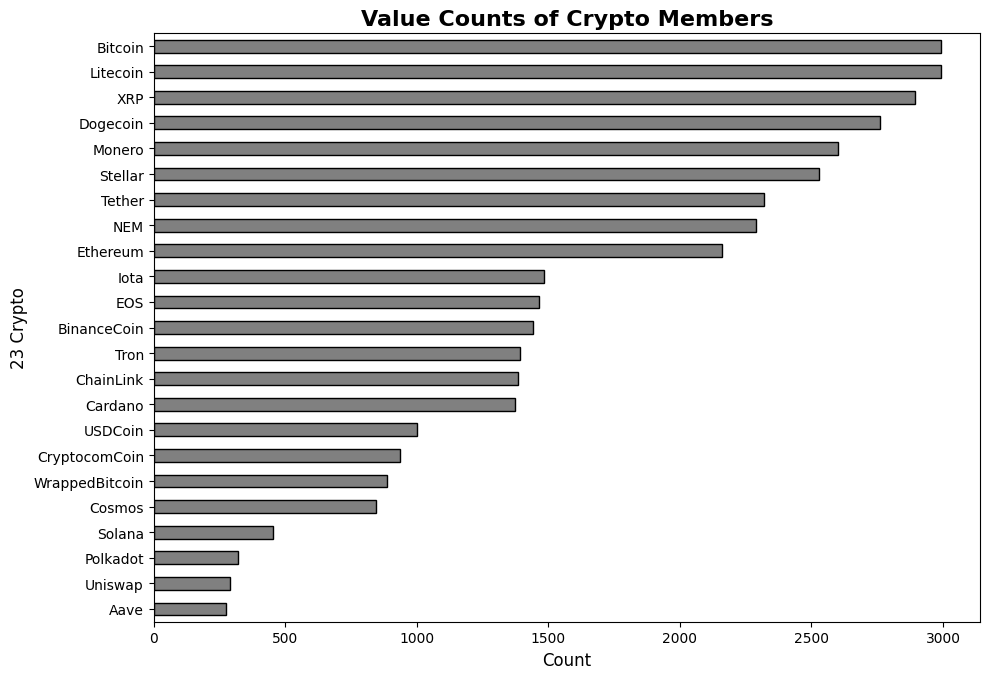

In [4]:
# Value counts of Crypto Members
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, max(6, len(df["Crypto"].unique()) * 0.3)))
df["Crypto"].value_counts().sort_values().plot(
    kind="barh", color="gray", edgecolor="black"
)

plt.title(
    "Value Counts of Crypto Members", fontsize=16, fontweight="bold"
)
plt.xlabel("Count", fontsize=12)
plt.ylabel("23 Crypto", fontsize=12)

plt.tight_layout()
plt.show()

In [5]:
# Group by 'Crypto' and compute the minimum (earliest) and maximum (latest) date
crypto_date_range = (
    df.groupby("Crypto")["Date"]
    .agg(Earliest_Date="min", Latest_Date="max")
    .reset_index()
)

# Calculate total active days for context
crypto_date_range["Total_Days"] = (
    crypto_date_range["Latest_Date"] - crypto_date_range["Earliest_Date"]
).dt.days

# Sort by Date
crypto_date_range = crypto_date_range.sort_values(by="Earliest_Date")

In [6]:
# Let's add a new column where the date on which the currency was created was written  
crypto_date_range['created_in'] = [
    "2009-01-03",  # Bitcoin
    "2011-10-13",  # Litecoin
    "2012-06-02",  # XRP
    "2013-12-06",  # Dogecoin
    "2014-04-18",  # Monero
    "2014-07-31",  # Stellar
    "2014-10-06",  # Tether
    "2015-03-31",  # NEM
    "2015-07-30",  # Ethereum
    "2016-07-11",  # Iota
    "2018-06-14",  # EOS
    "2017-07-14",  # BinanceCoin
    "2018-05-31",  # Tron
    "2017-09-19",  # ChainLink
    "2017-09-29",  # Cardano
    "2018-09-26",  # USDCoin
    "2018-11-14",  # CryptocomCoin (Cronos)
    "2019-01-31",  # WrappedBitcoin
    "2019-03-13",  # Cosmos
    "2020-03-16",  # Solana
    "2020-05-26",  # Polkadot
    "2018-11-02",  # Uniswap
    "2017-11-06",  # Aave (originally ETHLend)
]
display(crypto_date_range)

,Crypto,Earliest_Date,Latest_Date,Total_Days,created_in
2,Bitcoin,2013-01-05 23:59:00,2021-12-06 23:59:00,3257,2009-01-03
11,Litecoin,2013-04-29 23:59:59,2021-07-06 23:59:59,2990,2011-10-13
22,XRP,2013-08-05 23:59:59,2021-07-06 23:59:59,2892,2012-06-02
7,Dogecoin,2013-12-16 23:59:59,2021-07-06 23:59:59,2759,2013-12-06
12,Monero,2014-05-22 23:59:59,2021-07-06 23:59:59,2602,2014-04-18
16,Stellar,2014-08-06 23:59:59,2021-07-06 23:59:59,2526,2014-07-31
17,Tether,2015-02-26 23:59:59,2021-07-06 23:59:59,2322,2014-10-06
13,NEM,2015-04-02 23:59:59,2021-07-06 23:59:59,2287,2015-03-31
9,Ethereum,2015-08-08 23:59:59,2021-07-06 23:59:59,2159,2015-07-30
10,Iota,2017-06-14 23:59:59,2021-07-06 23:59:59,1483,2016-07-11


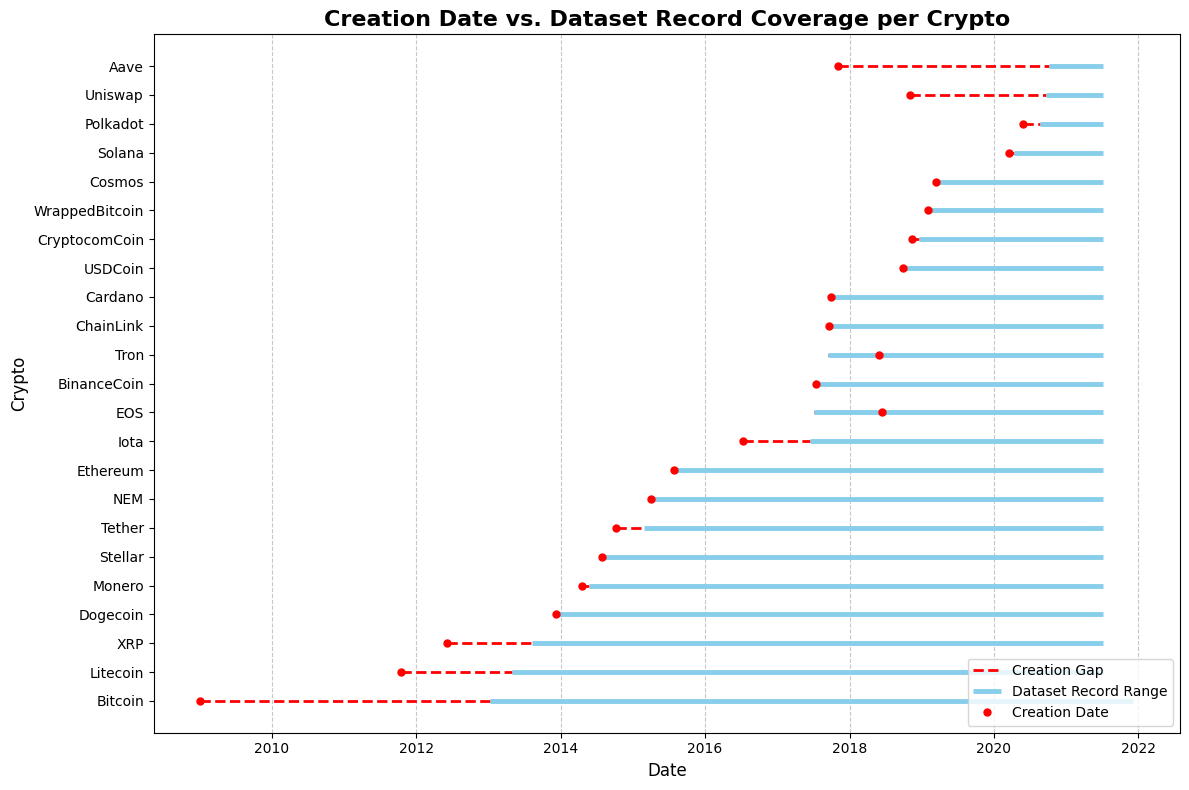

In [7]:
# Ensure 'created_in' is converted to datetime format
crypto_date_range["created_in"] = pd.to_datetime(
    crypto_date_range["created_in"]
)

plt.figure(figsize=(12, 8))

for idx, row in crypto_date_range.iterrows():
    # Red line: Creation date to earliest record in dataset
    plt.hlines(
        y=row["Crypto"],
        xmin=row["created_in"],
        xmax=row["Earliest_Date"],
        color="red",
        linewidth=2,
        linestyle="--",
        label="Creation Gap" if idx == crypto_date_range.index[0] else "",
    )

    # Skyblue line: Earliest record date to latest record date in dataset
    plt.hlines(
        y=row["Crypto"],
        xmin=row["Earliest_Date"],
        xmax=row["Latest_Date"],
        color="skyblue",
        linewidth=3.5,
        label="Dataset Record Range"
        if idx == crypto_date_range.index[0]
        else "",
    )

    # Red point at the exact creation date
    plt.plot(
        row["created_in"],
        row["Crypto"],
        "ro",
        markersize=5,
        label="Creation Date" if idx == crypto_date_range.index[0] else "",
    )

plt.title(
    "Creation Date vs. Dataset Record Coverage per Crypto",
    fontsize=16,
    fontweight="bold",
)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Crypto", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [8]:
# 1. Ensure Date is in datetime format and normalize to remove times (if any)
df["Date"] = pd.to_datetime(df["Date"]).dt.normalize()

# 2. Check for missing days per Crypto
continuity_results = []

for crypto, group in df.groupby("Crypto"):
    # Sort dates sequentially
    dates = group["Date"].sort_values().drop_duplicates()

    earliest = dates.min()
    latest = dates.max()

    # Actual number of unique days recorded
    actual_days = dates.nunique()

    # Expected number of days if continuous (inclusive range)
    expected_days = (latest - earliest).days + 1

    # Missing days count
    missing_days_count = expected_days - actual_days

    # Identify exact missing dates if any
    if missing_days_count > 0:
        full_date_range = pd.date_range(start=earliest, end=latest, freq="D")
        missing_dates = full_date_range.difference(dates)
    else:
        missing_dates = []

    continuity_results.append(
        {
            "Crypto": crypto,
            "Earliest_Date": earliest.strftime("%Y-%m-%d"),
            "Latest_Date": latest.strftime("%Y-%m-%d"),
            "Actual_Days": actual_days,
            "Expected_Days": expected_days,
            "Is_Continuous": missing_days_count == 0,
            "Missing_Days_Count": missing_days_count,
            "Missing_Dates": [
                d.strftime("%Y-%m-%d") for d in missing_dates[:5]
            ],  # Preview first 5 missing dates
        }
    )

# 3. Create DataFrame
continuity_df = pd.DataFrame(continuity_results)

# Display summary table
display(
    continuity_df[
        [
            "Crypto",
            "Earliest_Date",
            "Latest_Date",
            "Actual_Days",
            "Expected_Days",
            "Is_Continuous",
            "Missing_Days_Count",
        ]
    ]
)

# Print cryptocurrencies that have gaps
gaps_exist = continuity_df[~continuity_df["Is_Continuous"]]
if not gaps_exist.empty:
    print("\n⚠️ Cryptocurrencies with missing dates found:")
    display(gaps_exist[["Crypto", "Missing_Days_Count", "Missing_Dates"]])
else:
    print("\n✅ All cryptocurrencies have continuous daily records!")

,Crypto,Earliest_Date,Latest_Date,Actual_Days,Expected_Days,Is_Continuous,Missing_Days_Count
0,Aave,2020-10-05,2021-07-06,275,275,True,0
1,BinanceCoin,2017-07-26,2021-07-06,1442,1442,True,0
2,Bitcoin,2013-01-05,2021-12-06,2991,3258,False,267
3,Cardano,2017-10-02,2021-07-06,1374,1374,True,0
4,ChainLink,2017-09-21,2021-07-06,1385,1385,True,0
5,Cosmos,2019-03-15,2021-07-06,845,845,True,0
6,CryptocomCoin,2018-12-15,2021-07-06,935,935,True,0
7,Dogecoin,2013-12-16,2021-07-06,2760,2760,True,0
8,EOS,2017-07-02,2021-07-06,1466,1466,True,0
9,Ethereum,2015-08-08,2021-07-06,2160,2160,True,0



⚠️ Cryptocurrencies with missing dates found:


,Crypto,Missing_Days_Count,Missing_Dates
2,Bitcoin,267,"[2013-01-13, 2013-01-14, 2013-01-15, 2013-01-1..."
12,Monero,1,[2014-06-05]
17,Tether,5,"[2015-02-27, 2015-02-28, 2015-03-01, 2015-03-0..."


In [9]:
df[df['SNo'] == 1]

,SNo,Name,Symbol,Date,High,Low,Open,Close,Volume,Marketcap,Crypto
0,1,Aave,AAVE,2020-10-05,55.112358,49.787900,52.675035,53.219243,0.000000e+00,8.912813e+07,Aave
275,1,Binance Coin,BNB,2017-07-26,0.109013,0.099266,0.105893,0.105138,2.003950e+05,1.051380e+07,BinanceCoin
1749,1,Bitcoin,BTC,2013-04-29,147.488007,134.000000,134.444000,144.539993,0.000000e+00,1.603769e+09,Bitcoin
4708,1,Cardano,ADA,2017-10-02,0.030088,0.019969,0.024607,0.025932,5.764130e+07,6.288991e+08,Cardano
6082,1,Chainlink,LINK,2017-09-21,0.207892,0.155292,0.189132,0.169680,2.126270e+06,5.938800e+07,ChainLink
7467,1,Cosmos,ATOM,2019-03-15,7.715249,6.432468,6.633174,7.504351,6.057301e+06,0.000000e+00,Cosmos
8312,1,Crypto.com Coin,CRO,2018-12-15,0.019845,0.016150,0.019542,0.017243,9.897096e+05,0.000000e+00,CryptocomCoin
9247,1,Dogecoin,DOGE,2013-12-16,0.000866,0.000150,0.000299,0.000205,0.000000e+00,1.509085e+06,Dogecoin
12007,1,EOS,EOS,2017-07-02,2.877510,0.822648,0.996521,2.710050,3.204520e+08,0.000000e+00,EOS
13473,1,Ethereum,ETH,2015-08-08,2.798810,0.714725,2.793760,0.753325,6.741880e+05,4.548689e+07,Ethereum


In [10]:
df[df['Marketcap'] == 0]

,SNo,Name,Symbol,Date,High,Low,Open,Close,Volume,Marketcap,Crypto
7467,1,Cosmos,ATOM,2019-03-15,7.715249,6.432468,6.633174,7.504351,6.057301e+06,0.0,Cosmos
7468,2,Cosmos,ATOM,2019-03-16,8.305615,6.694531,7.507990,7.383882,3.477393e+06,0.0,Cosmos
7469,3,Cosmos,ATOM,2019-03-17,7.357443,4.727895,7.357443,4.776164,2.653565e+06,0.0,Cosmos
7470,4,Cosmos,ATOM,2019-03-18,5.229982,4.828242,4.828242,5.110341,2.567201e+06,0.0,Cosmos
7471,5,Cosmos,ATOM,2019-03-19,5.206172,4.794501,5.099978,4.821883,3.891084e+06,0.0,Cosmos
...,...,...,...,...,...,...,...,...,...,...,...
33492,192,Wrapped Bitcoin,WBTC,2019-08-10,11925.679833,11344.534410,11905.712514,11387.724877,7.122426e+04,0.0,WrappedBitcoin
33493,193,Wrapped Bitcoin,WBTC,2019-08-11,11712.839050,11255.921397,11389.198069,11517.323840,1.358500e+05,0.0,WrappedBitcoin
33494,194,Wrapped Bitcoin,WBTC,2019-08-12,11607.908092,11385.550446,11515.733133,11430.226183,7.705288e+04,0.0,WrappedBitcoin
33495,195,Wrapped Bitcoin,WBTC,2019-08-13,11447.922205,10916.591228,11435.761096,11025.733953,7.731779e+04,0.0,WrappedBitcoin


### Notes
- Doesn't look like the Name column is of any use. I have to delete that.
- Some volume columns are 0, which shows unavailable data on the early dates, so I have to deal with them somehow.
- The final record date for all the crypto is the same, but the starting date is different for all.
- Ok, after putting the date on which the crypto was created, these starting date differences make sense.
- I think instead of all the currencies, I should analyse specific numbers (maybe), and what with the EOS and Tron date, I'm gonna pretend like I didn't see it.
- Most of the dates are continuous instead of Crypto, but the left-out dates are too small; it hardly matters.
- I think that's enough understanding of Data. 